# Cancer Prediction

Cancer is a serious issue facing society today. Just in the US, the National Cancer Institute reported that, “an estimated 2,041,910 new cases of cancer will be diagnosed in the United States and 618,120 people will die from the disease.” ([National Cancer Institute](<https://pmc.ncbi.nlm.nih.gov/articles/PMC2515569/)>)) While these figures highlight a major public health crisis, a big portion of these cases do not come from genetic defects. According to the National Library of Medicine, “Only 5–10% of all cancer cases can be attributed to genetic defects, whereas the remaining 90–95% have their roots in the environment and lifestyle.” ([PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC2515569/)) Together, these statistics emphasize the need for widespread initiatives to understand what the traits of a healthy lifestyle are.

### Group Member
- Adit Gautam
- Hsin Yu Ho
- Skyler Kim 
- Somprat Suratannon
- Noah Teng

### Research Question
Among individuals without a cancer diagnosis, what demographic, lifestyle, and risk factors are most common compared to those who are diagnosed?

### Hypothesis

Individuals without a cancer diagnosis past retirement age (65) are more likely to exhibit lower exposure to risk factors, such as smoking, alcohol consumption, and poor physical health compared to individuals who are diagnosed with cancer.

### Data
Our ideal data should include at least 1000 observations from a diverse demographic pool of patients that account for a wide range of ages, lifestyle habits, and physical fitness which would allow us to indicate the frequency of good and bad habits in the patient’s life. These variables would provide crucial information in showing whether these choices might lead to cancer or away from it. 

For these reasons we decided to use Rabie El Kharoua’s [Cancer Prediction Dataset](https://www.kaggle.com/datasets/rabieelkharoua/cancer-prediction-dataset) which was  synthetically generated with 1500 observations ranging from 20 to 80 years olds which included many lifestyle factors and basic health information. The dataset has 943 healthy patients and 557 cancer patients has 9 columns: 

- Age: Integer values representing the patient's age, ranging from 20 to 80.  
- Gender: Binary values representing gender, where 0 indicates Male and 1 indicates Female.
- BMI: Continuous values representing Body Mass Index, ranging from 15 to 40.  
- Smoking: Binary values indicating smoking status, where 0 means No and 1 means Yes.
- GeneticRisk: Categorical values representing genetic risk levels for cancer ranging from 0 to 2, with 0 indicating Low, 1 indicating Medium, and 2 indicating High.  
- Physical Activity: Continuous values representing the number of hours per week spent on physical activities, ranging from 0 to 10.  
- AlcoholIntake: Continuous values representing the number of alcohol units consumed per week, ranging from 0 to 5.  
- CancerHistory: Binary values indicating whether the patient has a personal history of cancer, where 0 means No and 1 means Yes.  
- Diagnosis: Binary values indicating the cancer diagnosis status, where 0 indicates No Cancer and 1 indicates Cancer.

Dataset Name: 🩺📊 Cancer Prediction Dataset 🌟🔬

Link to the dataset: https://www.kaggle.com/datasets/rabieelkharoua/cancer-prediction-dataset 

### Coding



In [106]:
import pandas as pd
import numpy as np
import statistics
import seaborn as sns
import plotly.express as px
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.style as style
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import ttest_ind, normaltest
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [107]:
cancer = pd.read_csv('The_Cancer_data_1500_V2.csv')
cancer

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1
...,...,...,...,...,...,...,...,...,...
1495,62,1,25.090025,0,0,9.892167,1.284158,0,1
1496,31,0,33.447125,0,1,1.668297,2.280636,1,1
1497,63,1,32.613861,1,1,0.466848,0.150101,0,1
1498,55,0,25.568216,0,0,7.795317,1.986138,1,1


Columns:
- Age: Integer values; range: 20 to 80.  
- Gender: Binary values; 0: Male, 1: Female.
- BMI: Continuous values; range: 15 to 40.  
- Smoking: Binary values; 0: No, 1: Yes.
- GeneticRisk: Categorical values; 0: Low, 1: Medium, 2: High.  
- Physical Activity: Continuous values; range: 0 to 10.  
- AlcoholIntake: Continuous values; range: 0 to 5.  
- CancerHistory: Binary values; 0: No, 1: Yes.  
- Diagnosis: Binary values; 0: No Cancer, 1: Cancer.


In [108]:
continous_cols = ['Age', 'PhysicalActivity', 'AlcoholIntake', 'BMI']
categorical_cols = ["Smoking", "Gender", "GeneticRisk", "CancerHistory"]

Check NaN/ missing values.

In [109]:
print(cancer.isnull().any())
print('Number of NaN values in the dataset: ' + str(cancer.isnull().sum().sum()))

Age                 False
Gender              False
BMI                 False
Smoking             False
GeneticRisk         False
PhysicalActivity    False
AlcoholIntake       False
CancerHistory       False
Diagnosis           False
dtype: bool
Number of NaN values in the dataset: 0


The dataset is tidy.

Then, use the Interquartile Range (IQR) method to identify if any outliers in the dataset.

Outliers in 'Age': []
Outliers in 'PhysicalActivity': []
Outliers in 'AlcoholIntake': []
Outliers in 'BMI': []


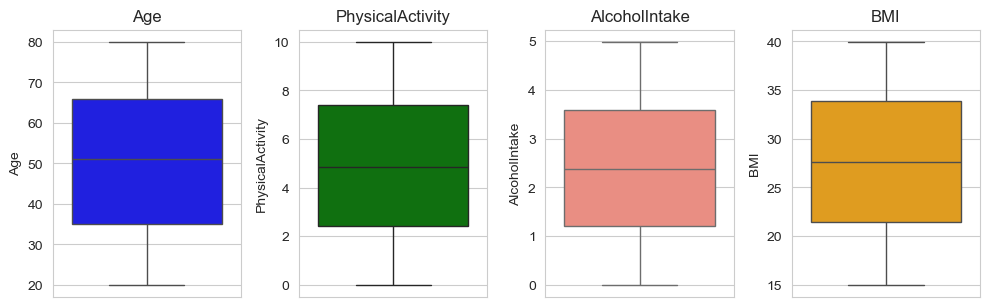

In [110]:
outliers = {}
for col in continous_cols:
    Q1 = cancer[col].quantile(0.25)
    Q3 = cancer[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_idx = cancer[(cancer[col] < lower_bound) | (cancer[col] > upper_bound)].index
    outliers[col] = outlier_idx.append(outlier_idx).tolist()
    print(f"Outliers in '{col}':", outliers[col])
    
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'salmon', 'orange']
for i, col in enumerate(continous_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=cancer[col], color=colors[i % len(colors)])
    plt.title(col)
plt.tight_layout()
plt.show()

No outliers.

In [111]:
cancer.describe()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000


In [112]:
df = cancer.copy()
df['Gender'] = df['Gender'].map({0: 'Male', 1: 'Female'})   
df.groupby('Gender').count()['Smoking']

Gender
Female    736
Male      764
Name: Smoking, dtype: int64

## Relationship

### Correlation Heatmap
Visualizing a correlation heatmap of age, PhysicalActivity, BMI, and AlcoholIntake.

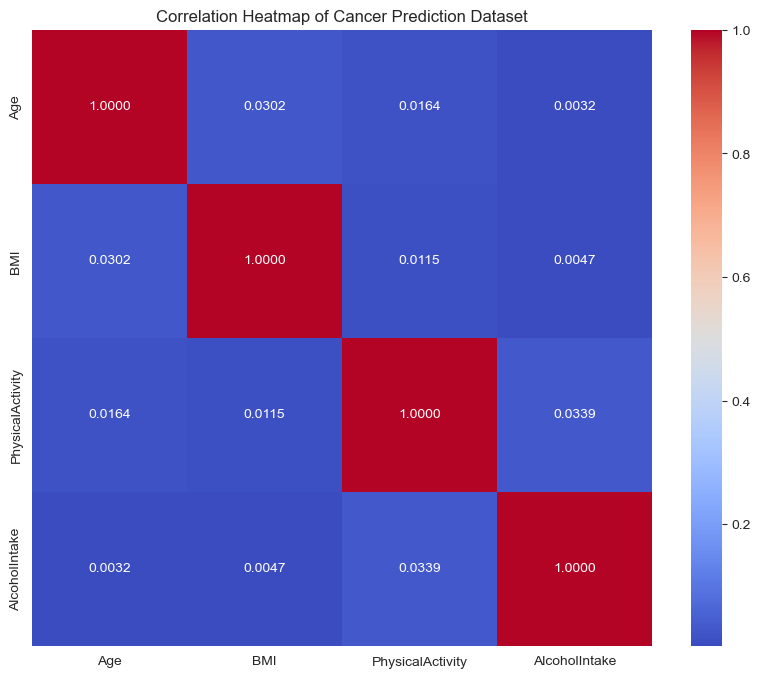

In [113]:
plt.figure(figsize=(10, 8))
for_heatmap = cancer[['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']]
corr = sns.heatmap(for_heatmap.corr(), annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Correlation Heatmap of Cancer Prediction Dataset')
plt.show()

### Density Plots
To see relationship between continuous and categorical variables, we use density plots to see the relationship.

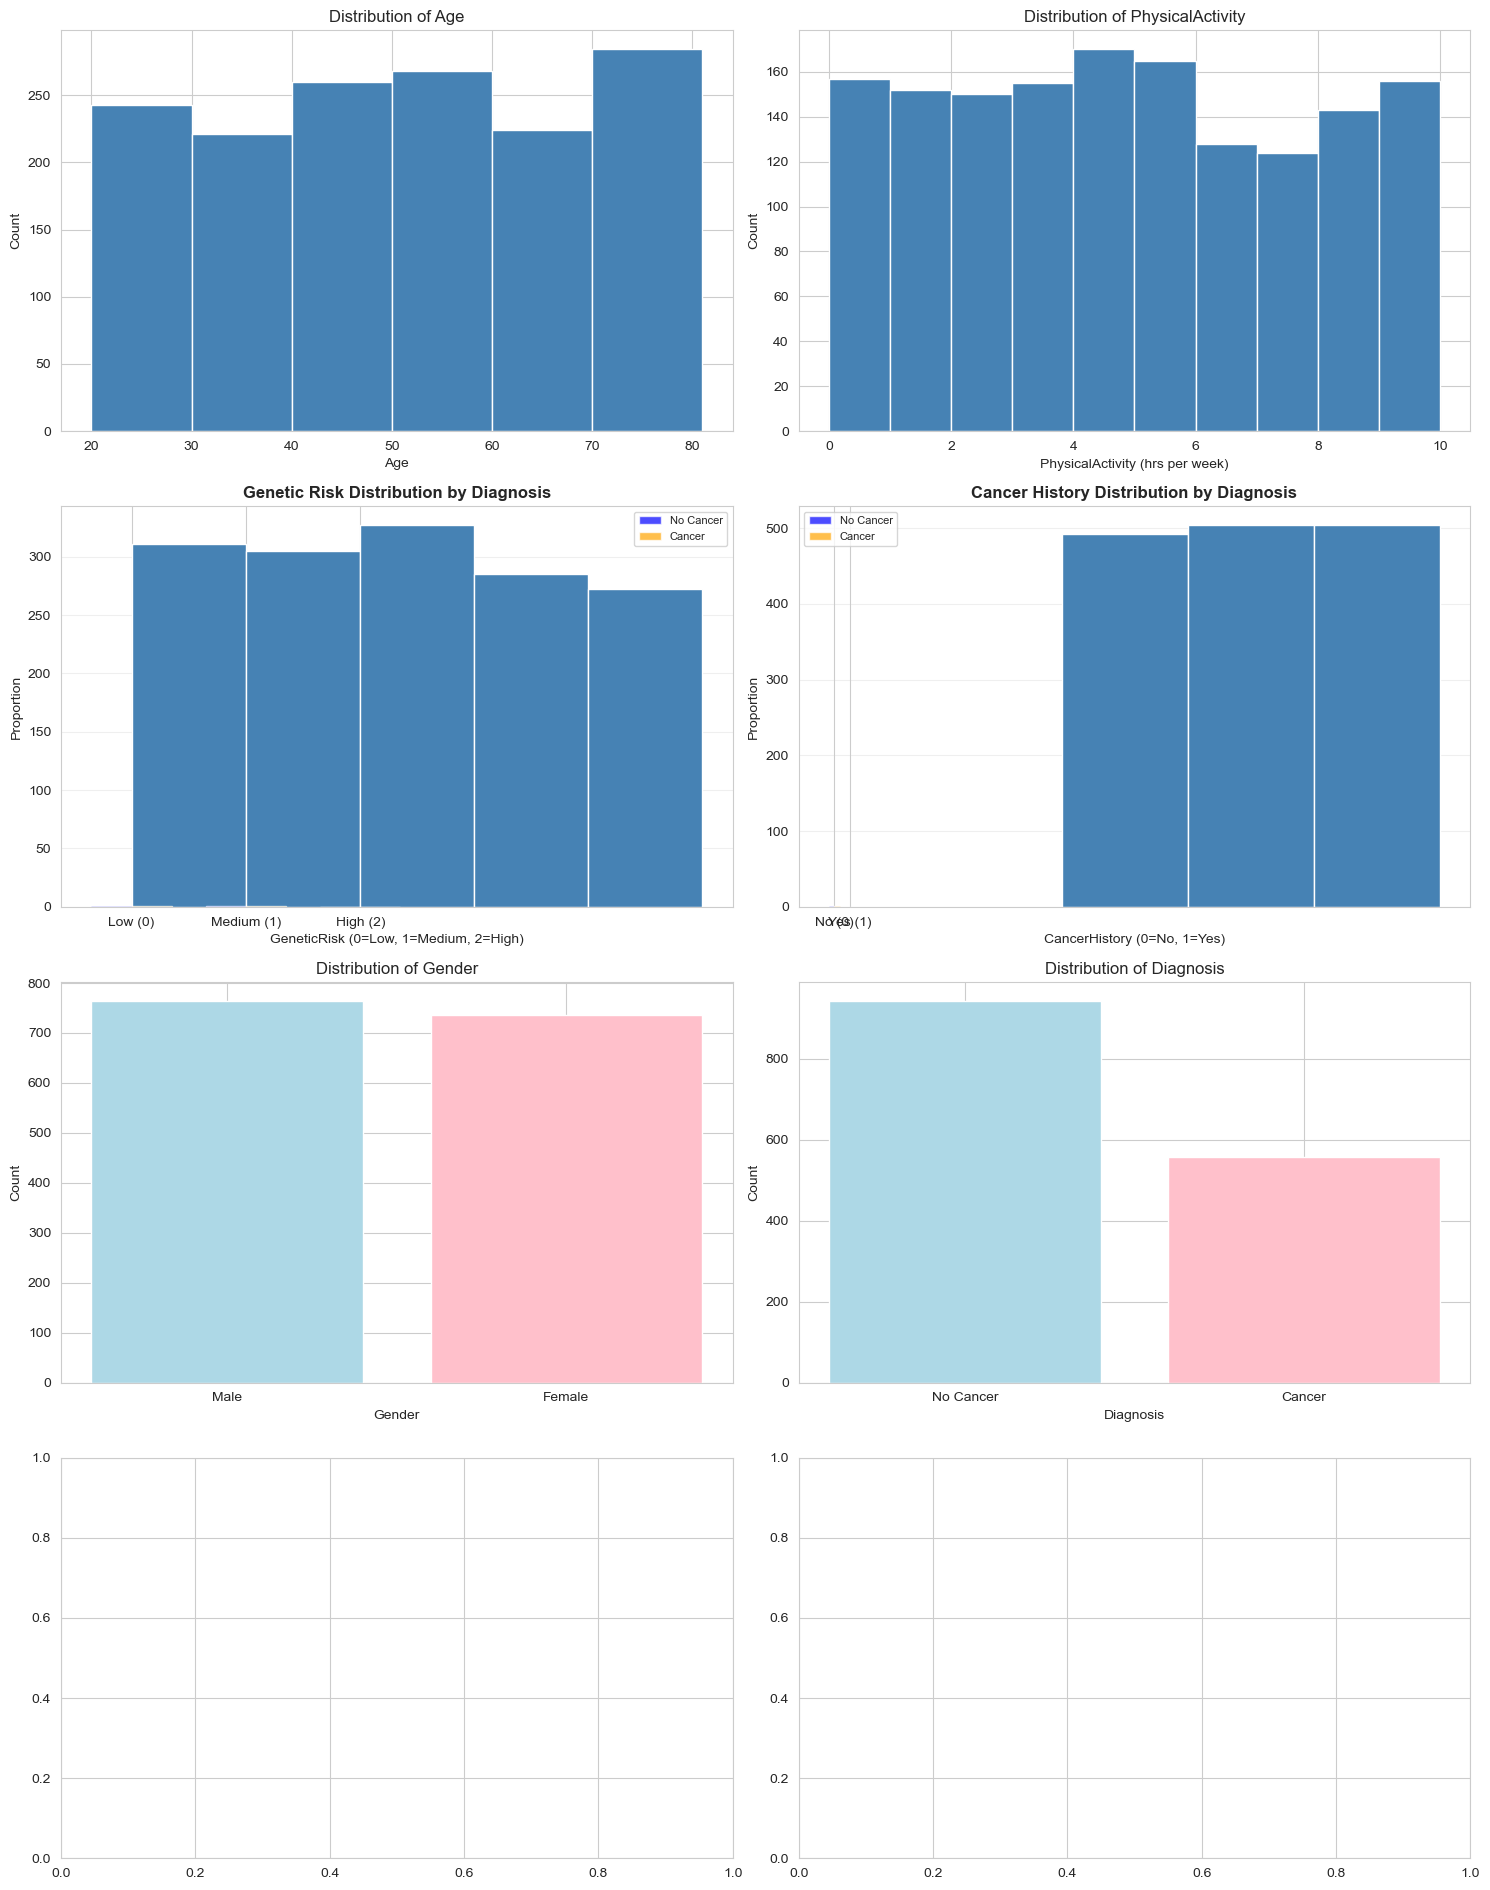

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(15, 19))
axes = axes.ravel()

age_bins = [20, 30, 40, 50, 60, 70, 81]
axes[0].hist(cancer['Age'], bins=age_bins, color='lightblue')
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel('Age')
axes[0].set_ylabel("Count")

axes[1].hist(cancer['PhysicalActivity'], bins=10, color='lightbluee')
axes[1].set_title("Distribution of PhysicalActivity")
axes[1].set_xlabel('PhysicalActivity (hrs per week)')
axes[1].set_ylabel("Count")

axes[2].hist(cancer['AlcoholIntake'], bins=5, color='lightblue')
axes[2].set_title("Distribution of AlcoholIntake")
axes[2].set_xlabel('AlcoholIntake (units consumed per week)')
axes[2].set_ylabel("Count")

axes[3].hist(cancer['BMI'], bins=3, color='lightblue')
axes[3].set_title("Distribution of BMI")
axes[3].set_xlabel('BMI (15-40)')
axes[3].set_ylabel("Count")

# Gender plot
gender_counts = cancer['Gender'].value_counts().sort_index()
axes[4].bar(['Male', 'Female'], gender_counts, color=['lightblue', 'pink'])
axes[4].set_xlabel('Gender')
axes[4].set_ylabel('Count')
axes[4].set_title('Distribution of Gender')


# Smoking plot
cancer_counts = cancer['Diagnosis'].value_counts().sort_index()
axes[5].bar(['No Cancer', 'Cancer'], cancer_counts, color=['lightblue', 'pink'])
axes[5].set_xlabel('Diagnosis')
axes[5].set_ylabel('Count')
axes[5].set_title('Distribution of Diagnosis')

# GeneticRisk plot
x_risk = np.arange(len(risk_no))
axes[2].bar(x_risk - width/2, risk_no.values, width, label='No Cancer', color='blue', alpha=0.7)
axes[2].bar(x_risk + width/2, risk_cancer.values, width, label='Cancer', color='orange', alpha=0.7)
axes[2].set_xlabel('GeneticRisk (0=Low, 1=Medium, 2=High)', fontsize=10)
axes[2].set_ylabel('Proportion', fontsize=10)
axes[2].set_title('Genetic Risk Distribution by Diagnosis', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_risk)
axes[2].set_xticklabels(['Low (0)', 'Medium (1)', 'High (2)'])
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

# CancerHistory plot
history_no = no_cancer['CancerHistory'].value_counts(normalize=True).sort_index()
history_cancer = with_cancer['CancerHistory'].value_counts(normalize=True).sort_index()
axes[3].bar(x - width/2, history_no.values, width, label='No Cancer', color='blue', alpha=0.7)
axes[3].bar(x + width/2, history_cancer.values, width, label='Cancer', color='orange', alpha=0.7)
axes[3].set_xlabel('CancerHistory (0=No, 1=Yes)', fontsize=10)
axes[3].set_ylabel('Proportion', fontsize=10)
axes[3].set_title('Cancer History Distribution by Diagnosis', fontsize=12, fontweight='bold')
axes[3].set_xticks(x)
axes[3].set_xticklabels(['No (0)', 'Yes (1)'])
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

We can see that the age in range [70, 80] is more than age in range [30, 40).

In [115]:
count_max = cancer[(cancer['Age'] >= 50) & (cancer['Age'] <= 80)]['Age'].count()
count_min = cancer[(cancer['Age'] >= 20) & (cancer['Age'] < 50)]['Age'].count()
age_diff = count_max - count_min
age_diff

np.int64(52)

Since there are 52 more patients in the age range [50, 81) than in [20, 50), the dataset is skewed toward older patients. This imbalance may bias statistical analysis and predictive models toward patterns associated with older individuals.

### Bar Plots 
Categorical Variables

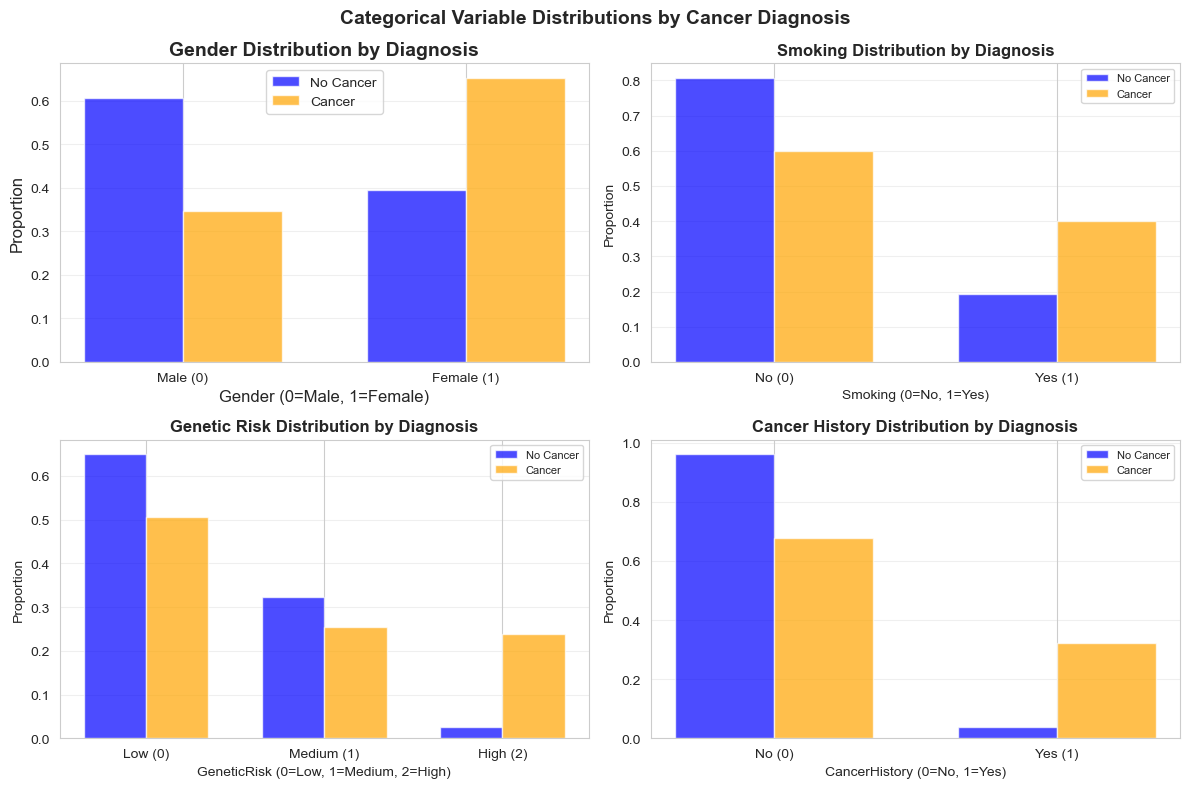

In [117]:
# Create bar plots for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
no_cancer = cancer[cancer['Diagnosis']==0]
with_cancer = cancer[cancer['Diagnosis']==1]
# Gender plot
gender_no = no_cancer['Gender'].value_counts(normalize=True).sort_index()
gender_cancer = with_cancer['Gender'].value_counts(normalize=True).sort_index()
x = np.arange(len(gender_no))
width = 0.35
axes[0].bar(x - width/2, gender_no.values, width, label='No Cancer', color='blue', alpha=0.7)
axes[0].bar(x + width/2, gender_cancer.values, width, label='Cancer', color='orange', alpha=0.7)
axes[0].set_xlabel('Gender (0=Male, 1=Female)', fontsize=12)
axes[0].set_ylabel('Proportion', fontsize=12)
axes[0].set_title('Gender Distribution by Diagnosis', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Male (0)', 'Female (1)'])
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Smoking plot
smoking_no = no_cancer['Smoking'].value_counts(normalize=True).sort_index()
smoking_cancer = with_cancer['Smoking'].value_counts(normalize=True).sort_index()
axes[1].bar(x - width/2, smoking_no.values, width, label='No Cancer', color='blue', alpha=0.7)
axes[1].bar(x + width/2, smoking_cancer.values, width, label='Cancer', color='orange', alpha=0.7)
axes[1].set_xlabel('Smoking (0=No, 1=Yes)', fontsize=10)
axes[1].set_ylabel('Proportion', fontsize=10)
axes[1].set_title('Smoking Distribution by Diagnosis', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['No (0)', 'Yes (1)'])
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

# GeneticRisk plot
risk_no = no_cancer['GeneticRisk'].value_counts(normalize=True).sort_index()
risk_cancer = with_cancer['GeneticRisk'].value_counts(normalize=True).sort_index()
x_risk = np.arange(len(risk_no))
axes[2].bar(x_risk - width/2, risk_no.values, width, label='No Cancer', color='blue', alpha=0.7)
axes[2].bar(x_risk + width/2, risk_cancer.values, width, label='Cancer', color='orange', alpha=0.7)
axes[2].set_xlabel('GeneticRisk (0=Low, 1=Medium, 2=High)', fontsize=10)
axes[2].set_ylabel('Proportion', fontsize=10)
axes[2].set_title('Genetic Risk Distribution by Diagnosis', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_risk)
axes[2].set_xticklabels(['Low (0)', 'Medium (1)', 'High (2)'])
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

# CancerHistory plot
history_no = no_cancer['CancerHistory'].value_counts(normalize=True).sort_index()
history_cancer = with_cancer['CancerHistory'].value_counts(normalize=True).sort_index()
axes[3].bar(x - width/2, history_no.values, width, label='No Cancer', color='blue', alpha=0.7)
axes[3].bar(x + width/2, history_cancer.values, width, label='Cancer', color='orange', alpha=0.7)
axes[3].set_xlabel('CancerHistory (0=No, 1=Yes)', fontsize=10)
axes[3].set_ylabel('Proportion', fontsize=10)
axes[3].set_title('Cancer History Distribution by Diagnosis', fontsize=12, fontweight='bold')
axes[3].set_xticks(x)
axes[3].set_xticklabels(['No (0)', 'Yes (1)'])
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3, axis='y')

plt.suptitle('Categorical Variable Distributions by Cancer Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [118]:
# Summary
print("Individuals WITHOUT Cancer vs WITH Cancer")

for col in continous_cols:
    print(f"\n{col}:")
    print(f"  No Cancer: Count: {len(no_cancer[col].dropna())}, Mean: {no_cancer[col].mean():.2f}, Std: {no_cancer[col].std():.2f}, Median: {no_cancer[col].median():.2f}")
    print(f"  With Cancer: Count: {len(with_cancer[col].dropna())}, Mean: {with_cancer[col].mean():.2f}, Std: {with_cancer[col].std():.2f}, Median: {with_cancer[col].median():.2f}")

print("PROPORTIONS FOR CATEGORICAL VARIABLES:")

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  No Cancer (n={len(no_cancer)}):")
    proportions_no = no_cancer[col].value_counts(normalize=True).sort_index()
    for val, prop in proportions_no.items():
        print(f"    Value {val}: {prop:.2%}")
    print(f"  With Cancer (n={len(with_cancer)}):")
    proportions_cancer = with_cancer[col].value_counts(normalize=True).sort_index()
    for val, prop in proportions_cancer.items():
        print(f"    Value {val}: {prop:.2%}")

Individuals WITHOUT Cancer vs WITH Cancer

Age:
  No Cancer: Count: 943, Mean: 47.66, Std: 17.57, Median: 46.00
  With Cancer: Count: 557, Mean: 54.83, Std: 16.84, Median: 56.00

PhysicalActivity:
  No Cancer: Count: 943, Mean: 5.23, Std: 2.75, Median: 5.09
  With Cancer: Count: 557, Mean: 4.34, Std: 2.97, Median: 4.07

AlcoholIntake:
  No Cancer: Count: 943, Mean: 2.19, Std: 1.37, Median: 2.07
  With Cancer: Count: 557, Mean: 2.81, Std: 1.41, Median: 3.03

BMI:
  No Cancer: Count: 943, Mean: 26.47, Std: 7.36, Median: 25.46
  With Cancer: Count: 557, Mean: 29.28, Std: 6.65, Median: 29.83
PROPORTIONS FOR CATEGORICAL VARIABLES:

Smoking:
  No Cancer (n=943):
    Value 0: 80.81%
    Value 1: 19.19%
  With Cancer (n=557):
    Value 0: 59.96%
    Value 1: 40.04%

Gender:
  No Cancer (n=943):
    Value 0: 60.55%
    Value 1: 39.45%
  With Cancer (n=557):
    Value 0: 34.65%
    Value 1: 65.35%

GeneticRisk:
  No Cancer (n=943):
    Value 0: 65.01%
    Value 1: 32.34%
    Value 2: 2.65%
  Wit

# Saving and Exporting Notebooks

Save notebooks and export them to different formats like HTML or PDF.

In [119]:
# categorical (chi-squared) 
from scipy.stats import chi2_contingency, ttest_ind

# 1) Chi-squared (categoricals)
chi2s = []
for col in categorical_cols:
    contingency = pd.crosstab(cancer[col], cancer["Diagnosis"])
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    n = contingency.values.sum()
    r, k = contingency.shape

    cramer_v = np.sqrt(chi2 / (n * max(min(r - 1, k - 1), 1)))
    if cramer_v <= 0.1:
        cramer_v_stength = 'Weak'
    elif cramer_v <= 0.3:
        cramer_v_stength = 'Medium'
    else:
        cramer_v_stength = 'Strong'

    chi2s.append({
        "Chi-squared": chi2,
        "p-value": p_value,
        "Significant (p<0.05)": p_value < 0.5,
        "Cramér's V": cramer_v,
        "Cramér's V Strength": cramer_v_stength,
        })

chi2_df = pd.DataFrame(chi2s, index=categorical_cols).sort_values("p-value")
print("Chi-squared tests: Categorical feature vs Diagnosis")
display(chi2_df)

Chi-squared tests: Categorical feature vs Diagnosis


,Chi-squared,p-value,Significant (p<0.05),Cramér's V,Cramér's V Strength
CancerHistory,228.410798,1.324116e-51,True,0.390223,Strong
GeneticRisk,167.432582,4.390124e-37,True,0.334098,Strong
Gender,92.968527,5.313258e-22,True,0.248956,Medium
Smoking,76.237267,2.515495e-18,True,0.225444,Medium


CancerHistory and GeneticRisk show stronger association with diagnosis (higher χ² and strong V).

Gender and Smoking are highly significant, but weaker association strength than the top two (Medium V).

In [120]:
# Smoking-specific risk summary to answer: smoker vs non-smoker diagnosis difference
smoking_diag = pd.crosstab(cancer["Smoking"], cancer["Diagnosis"])

if set(smoking_diag.index) >= {0, 1} and set(smoking_diag.columns) >= {0, 1}:
    risk_non_smoker = smoking_diag.loc[0, 1] / smoking_diag.loc[0].sum()
    risk_smoker = smoking_diag.loc[1, 1] / smoking_diag.loc[1].sum()
    risk_ratio = risk_smoker / risk_non_smoker if risk_non_smoker > 0 else np.nan

    print("\nSmoking risk:")
    print(f"Diagnosis rate (non-smokers): {risk_non_smoker:.3f}")
    print(f"Diagnosis rate (smokers):     {risk_smoker:.3f}")
    print(f"Risk ratio (smoker/non):      {risk_ratio:.3f}")

    if risk_ratio > 1:
        print("\nSmoking is associated with increased cancer risk.")
    else:
        print("\nSmoking is associated with decreased cancer risk.")


Smoking risk:
Diagnosis rate (non-smokers): 0.305
Diagnosis rate (smokers):     0.552
Risk ratio (smoker/non):      1.811

Smoking is associated with increased cancer risk.


In [121]:
# T-tests (continuous tests)
tests = []

for col in continous_cols:
    group_no = cancer.loc[cancer["Diagnosis"] == 0, col].dropna()
    group_yes = cancer.loc[cancer["Diagnosis"] == 1, col].dropna()

    t_stat, p_value = ttest_ind(group_no, group_yes, equal_var=False)

    n1, n2 = len(group_no), len(group_yes)
    s1, s2 = group_no.std(ddof=1), group_yes.std(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    
    cohen_d = np.abs((group_yes.mean() - group_no.mean()) / pooled_sd) if pooled_sd > 0 else np.nan
    if cohen_d < 0.2:
        cohen_d_strength = 'Small'
    elif cohen_d < 0.5:
        cohen_d_strength = 'Medium'
    else:
        cohen_d_strength = 'Large' 

    tests.append({
        "Mean No-Diagnosis": group_no.mean(),
        "Mean Diagnosis": group_yes.mean(),
        "t-stat": t_stat,
        "p-value": p_value,
        "Significant (p<0.05)": p_value < 0.5,
        "|Cohen’s d|": cohen_d,
        "Cohen’s d strength": cohen_d_strength,
        })

ttest_df = pd.DataFrame(tests, index=continous_cols).sort_values("p-value")
print("\nt-tests: Continuous feature means by Diagnosis")
display(ttest_df)


t-tests: Continuous feature means by Diagnosis


,Mean No-Diagnosis,Mean Diagnosis,t-stat,p-value,Significant (p<0.05),|Cohen’s d|,Cohen’s d strength
AlcoholIntake,2.185970,2.810793,-8.362728,1.771755e-16,True,0.450394,Medium
Age,47.655355,54.831239,-7.846796,9.350830e-15,True,0.414732,Medium
BMI,26.471469,29.277175,-7.584778,6.435918e-14,True,0.394943,Medium
PhysicalActivity,5.228432,4.338388,5.761972,1.079336e-08,True,0.313988,Medium


Patient diagnosis with cancer:

- They drinks more on average; medium effect (|Cohen’s d|≈0.45).

- They are older on average; medium effect (|d|≈0.41).

- They have higher BMI on average; medium effect (|d|≈0.39).

- They exercise less on average; medium effect (|d|≈0.31)